In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
%matplotlib inline

In [2]:
cols = (
    ['engine_id', 'cycle'] +
    [f'op_{i}' for i in range(1, 4)] +
    [f's{i}' for i in range(1, 22)]  
)

train = pd.read_csv('./CMAPSSData/train_FD001.txt', sep=r'\s+', header=None, names=cols)
test = pd.read_csv('./CMAPSSData/test_FD001.txt', sep=r'\s+', header=None, names=cols)
rul = pd.read_csv('./CMAPSSData/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

In [3]:
print("Train:", train.shape)
print("Test: ", test.shape)
print("RUL: ", rul.shape)
print("Train nulls:", train.isnull().sum().sum())
print("Test nulls:", test.isnull().sum().sum())
print("RUL nulls:", rul.isnull().sum().sum())
train.head()

Train: (20631, 26)
Test:  (13096, 26)
RUL:  (100, 1)
Train nulls: 0
Test nulls: 0
RUL nulls: 0


,engine_id,cycle,op_1,op_2,op_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
#Step 1: get the failure cycle for each engine
max_cycles = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id' , 'max_cycle']

#Step 2: merge back and compute raw RUL
train = train.merge(max_cycles, on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop(columns='max_cycle', inplace=True)

#step 3: apply piecewise cap at 125
train['RUL'] = train['RUL'].clip(upper=125)



<function matplotlib.pyplot.show(close=None, block=None)>

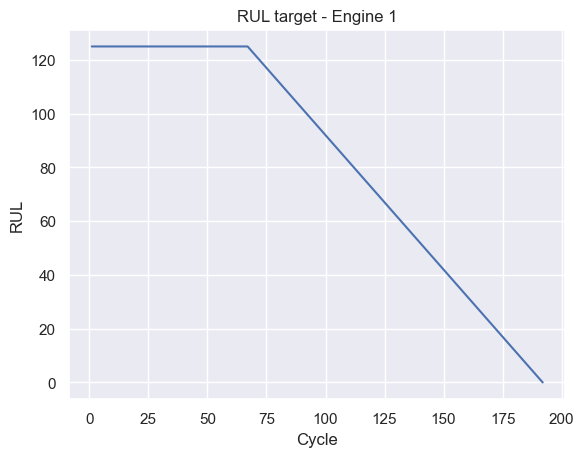

In [5]:
#Check one engine
engine_1 = train[train['engine_id'] == 1]
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('RUL target - Engine 1')
plt.show

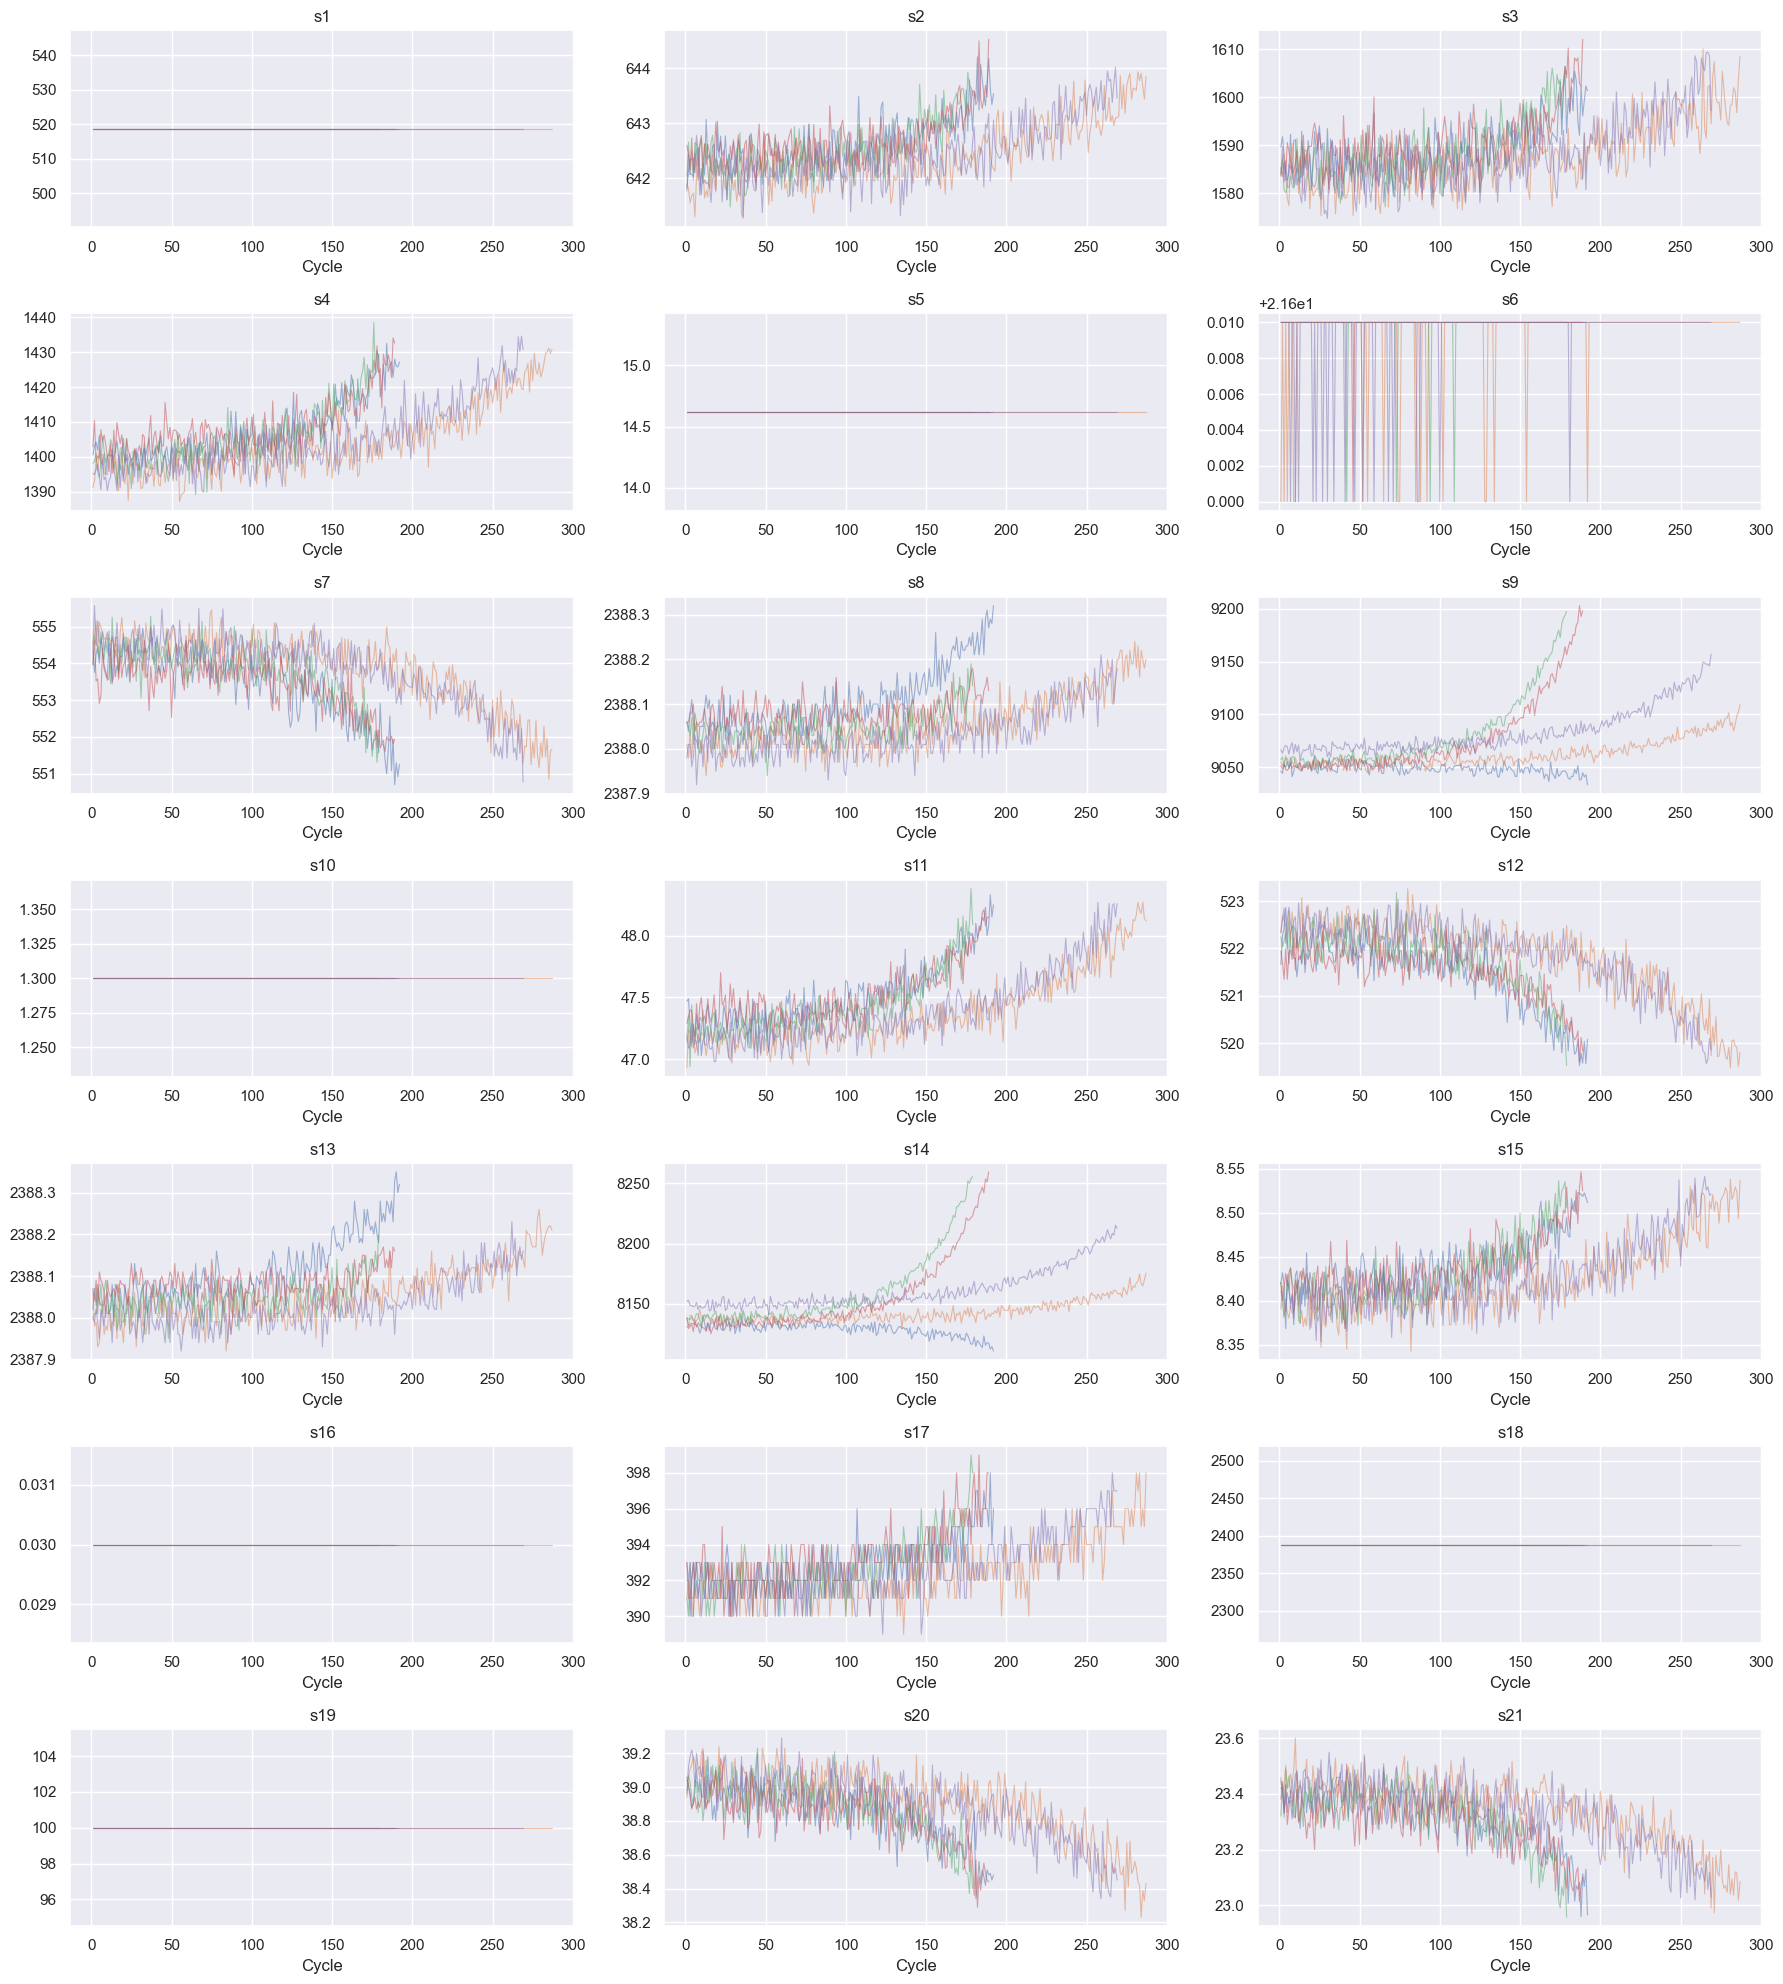

In [6]:
sensors = [f's{i}' for i in range(1, 22)]

fig, axes = plt.subplots(7, 3, figsize=(18, 20))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    for eng_id in [1, 2, 3, 4, 5]:
        subset = train[train['engine_id'] == eng_id]
        axes[i].plot(subset['cycle'], subset[sensor], alpha=0.5, linewidth=0.8)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.tight_layout()
plt.show()

In [7]:
#drop unhelpful sensors

drop_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
train = train.drop(columns=drop_sensors)
test = test.drop(columns=drop_sensors)

print("Remaining columns:", train.shape[1])



Remaining columns: 20


In [8]:
sensor_cols = [c for c in train.columns if c.startswith('s')]
variance = train[sensor_cols].var().sort_values()
print(variance)

s15      0.001407
s8       0.005039
s13      0.005172
s21      0.011718
s20      0.032669
s11      0.071336
s2       0.250053
s12      0.543985
s7       0.783388
s17      2.398667
s3      37.590994
s4      81.010886
s14    363.900490
s9     487.653568
dtype: float64


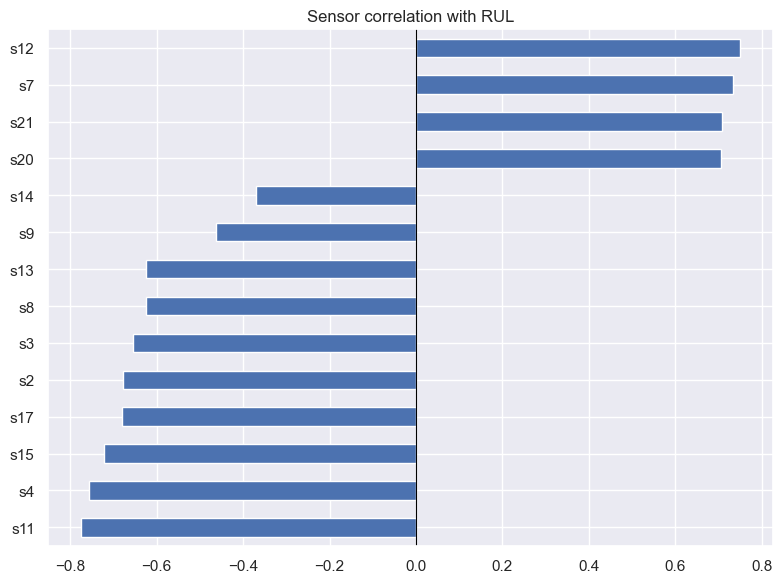

In [9]:
correlations = train[sensor_cols].corrwith(train['RUL']).sort_values()
correlations.plot(kind='barh', figsize=(8, 6), title='Sensor correlation with RUL')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

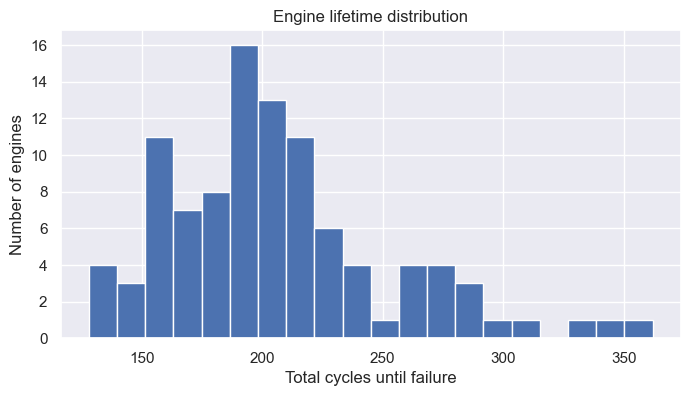

In [10]:
lifetimes = train.groupby('engine_id')['cycle'].max()
lifetimes.hist(bins=20, figsize=(8, 4))
plt.xlabel('Total cycles until failure')
plt.ylabel('Number of engines')
plt.title('Engine lifetime distribution')
plt.show()

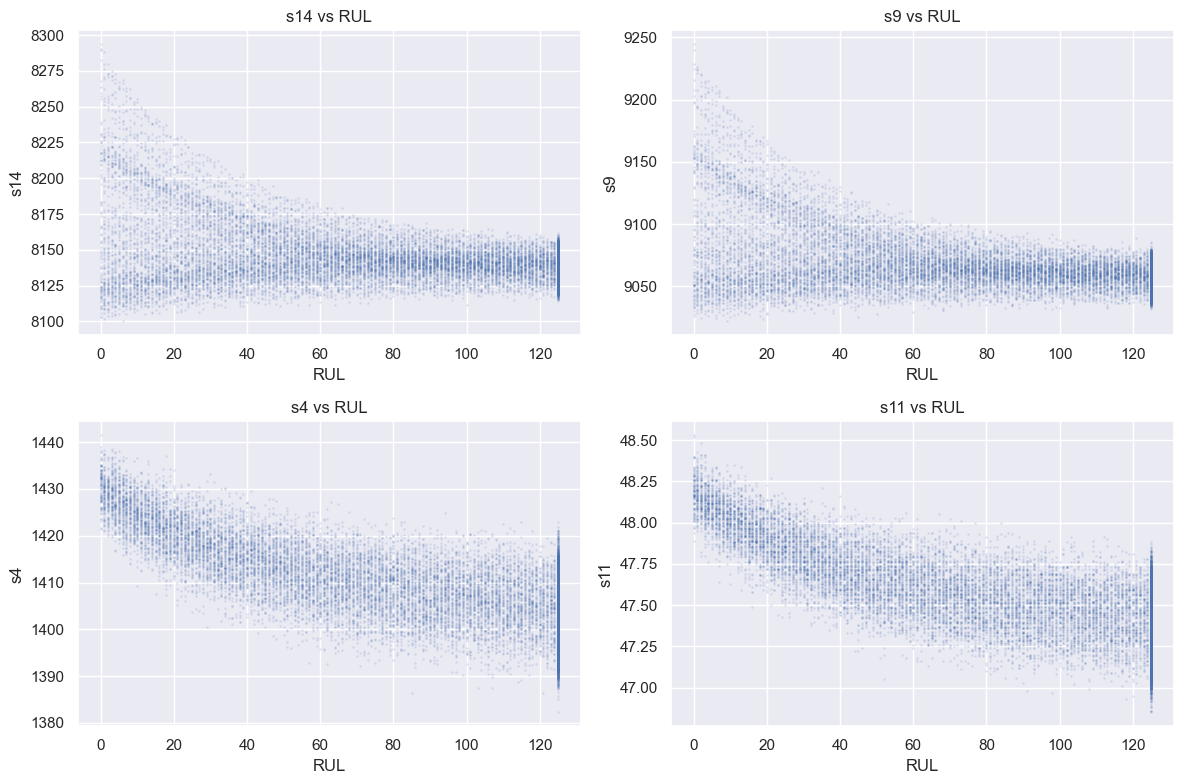

In [11]:
top_sensors = ['s14', 's9', 's4', 's11']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    axes[i].scatter(train['RUL'], train[sensor], alpha=0.1, s=1)
    axes[i].set_xlabel('RUL')
    axes[i].set_ylabel(sensor)
    axes[i].set_title(f'{sensor} vs RUL')

plt.tight_layout()
plt.show()

In [12]:
sensor_cols = [c for c in train.columns if c.startswith('s')]
window = 30

def add_rolling_features(df, sensors, window):
    df = df.sort_values(['engine_id', 'cycle'])
    for sensor in sensors:
        df[f'{sensor}_mean_{window}'] = (
            df.groupby('engine_id')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f'{sensor}_std_{window}'] = (
            df.groupby('engine_id')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        )
    return df

train = add_rolling_features(train, sensor_cols, window)
test  = add_rolling_features(test, sensor_cols, window)

print("Train shape after rolling features:", train.shape)

Train shape after rolling features: (20631, 48)


In [13]:
engine_1 = train[train['engine_id'] == 1][['cycle', 's4', 's4_mean_30', 's4_std_30']].head(40)
print(engine_1)

    cycle       s4   s4_mean_30  s4_std_30
0       1  1400.60  1400.600000   0.000000
1       2  1403.14  1401.870000   1.796051
2       3  1404.20  1402.646667   1.850009
3       4  1401.87  1402.452500   1.559645
4       5  1406.22  1403.206000   2.159440
5       6  1398.37  1402.400000   2.761949
6       7  1397.77  1401.738571   3.069101
7       8  1400.97  1401.642500   2.854399
8       9  1394.80  1400.882222   3.511601
9      10  1400.46  1400.840000   3.313461
10     11  1400.64  1400.821818   3.144003
11     12  1400.15  1400.765833   3.003956
12     13  1400.83  1400.770769   2.876124
13     14  1399.16  1400.655714   2.796624
14     15  1402.13  1400.754000   2.721646
15     16  1404.50  1400.988125   2.791158
16     17  1399.95  1400.927059   2.714230
17     18  1396.12  1400.660000   2.866611
18     19  1400.35  1400.643684   2.786753
19     20  1405.23  1400.873000   2.899822
20     21  1398.13  1400.742381   2.889084
21     22  1400.57  1400.734545   2.819697
22     23  